The following is an example of how to utilize our Sen1Floods11 dataset for training a FCNN. In this example, we train and validate on hand-labeled chips of flood events. However, our dataset includes several other options that are detailed in the README. To replace the dataset, as outlined further below, simply replace the train, test, and validation split csv's, and download the corresponding dataset.

Authenticate Google Cloud Platform. Note that to run this code, you must connect your notebook runtime to a GPU.

1

In [56]:
!pip install -q rasterio segmentation-models-pytorch

2

In [57]:
import csv
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("设备:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
设备: cuda
GPU: Tesla T4


3

In [58]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Sen1Floods11_UNet"
)

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("项目目录:", PROJECT_DIR)

Mounted at /content/drive
项目目录: /content/drive/MyDrive/Sen1Floods11_UNet


4

In [59]:
DATA_ROOT = Path("/content/sen1floods11")

S1_DIR = DATA_ROOT / "S1"
LABEL_DIR = DATA_ROOT / "Labels"
SPLIT_DIR = DATA_ROOT / "splits"

S1_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

5

In [60]:
!gsutil cp \
  gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv \
  /content/sen1floods11/splits/

!gsutil cp \
  gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv \
  /content/sen1floods11/splits/

!gsutil cp \
  gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv \
  /content/sen1floods11/splits/

!gsutil -m rsync -r \
  gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand \
  /content/sen1floods11/S1

!gsutil -m rsync -r \
  gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand \
  /content/sen1floods11/Labels

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv...
/ [1 files][ 13.3 KiB/ 13.3 KiB]                                                
Operation completed over 1 objects/13.3 KiB.                                     
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv...
/ [1 files][  4.7 KiB/  4.7 KiB]                                                
Operation completed over 1 objects/4.7 KiB.                                   

In [61]:
print("S1数量:", len(list(S1_DIR.glob("*.tif"))))
print("标签数量:", len(list(LABEL_DIR.glob("*.tif"))))
print("划分文件:", [p.name for p in SPLIT_DIR.glob("*.csv")])

S1数量: 446
标签数量: 446
划分文件: ['flood_train_data.csv', 'flood_valid_data.csv', 'flood_test_data.csv']


6

In [62]:
class Sen1Floods11Dataset(Dataset):
    def __init__(
        self,
        split_csv,
        s1_dir,
        label_dir,
        training=False,
        crop_size=256,
        water_crop_probability=0.6,
        min_water_pixels=100,
    ):
        self.s1_dir = Path(s1_dir)
        self.label_dir = Path(label_dir)
        self.training = training
        self.crop_size = crop_size
        self.water_crop_probability = water_crop_probability
        self.min_water_pixels = min_water_pixels

        self.items = []

        with open(split_csv, newline="") as f:
            for row in csv.reader(f):
                if len(row) < 2:
                    continue

                s1_name = Path(row[0]).name
                label_name = Path(row[1]).name

                s1_path = self.s1_dir / s1_name
                label_path = self.label_dir / label_name

                if not s1_path.exists():
                    raise FileNotFoundError(s1_path)

                if not label_path.exists():
                    raise FileNotFoundError(label_path)

                self.items.append(
                    (s1_name, label_name)
                )

        print(
            Path(split_csv).name,
            "样本数:",
            len(self.items),
        )

    def __len__(self):
        return len(self.items)

    def _water_aware_crop(self, image, mask):
        _, height, width = image.shape
        size = self.crop_size

        require_water = (
            random.random()
            < self.water_crop_probability
        )

        selected_top = 0
        selected_left = 0

        for _ in range(10):
            top = random.randint(0, height - size)
            left = random.randint(0, width - size)

            crop_mask = mask[
                top:top + size,
                left:left + size,
            ]

            selected_top = top
            selected_left = left

            if not require_water:
                break

            water_pixels = (
                crop_mask == 1
            ).sum().item()

            if water_pixels >= self.min_water_pixels:
                break

        image = image[
            :,
            selected_top:selected_top + size,
            selected_left:selected_left + size,
        ]

        mask = mask[
            selected_top:selected_top + size,
            selected_left:selected_left + size,
        ]

        return image, mask

    def __getitem__(self, index):
        s1_name, label_name = self.items[index]

        with rasterio.open(
            self.s1_dir / s1_name
        ) as src:
            image = src.read(
                [1, 2]
            ).astype(np.float32)

        with rasterio.open(
            self.label_dir / label_name
        ) as src:
            mask = src.read(1).astype(np.int64)

        # 与官方预处理一致
        image = np.nan_to_num(
            image,
            nan=0.0,
            posinf=1.0,
            neginf=-50.0,
        )

        image = np.clip(image, -50.0, 1.0)
        image = (image + 50.0) / 51.0

        mask[mask == -1] = 255

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).long()

        if self.training:
            image, mask = self._water_aware_crop(
                image,
                mask,
            )

            if random.random() < 0.5:
                image = torch.flip(image, dims=[2])
                mask = torch.flip(mask, dims=[1])

            if random.random() < 0.5:
                image = torch.flip(image, dims=[1])
                mask = torch.flip(mask, dims=[0])

            rotation_k = random.randint(0, 3)

            if rotation_k > 0:
                image = torch.rot90(
                    image,
                    rotation_k,
                    dims=[1, 2],
                )
                mask = torch.rot90(
                    mask,
                    rotation_k,
                    dims=[0, 1],
                )

        mean = torch.tensor(
            [0.6851, 0.5235],
            dtype=torch.float32,
        )[:, None, None]

        std = torch.tensor(
            [0.0820, 0.1102],
            dtype=torch.float32,
        )[:, None, None]

        image = (image - mean) / std

        return image, mask

7

In [63]:
train_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_train_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=True,
)

valid_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_valid_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

test_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_test_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

flood_train_data.csv 样本数: 252
flood_valid_data.csv 样本数: 89
flood_test_data.csv 样本数: 90


8

In [64]:
train_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_train_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=True,
)

valid_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_valid_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

test_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_test_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

flood_train_data.csv 样本数: 252
flood_valid_data.csv 样本数: 89
flood_test_data.csv 样本数: 90


In [65]:
train_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_train_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=True,
)

valid_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_valid_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

test_dataset = Sen1Floods11Dataset(
    SPLIT_DIR / "flood_test_data.csv",
    S1_DIR,
    LABEL_DIR,
    training=False,
)

flood_train_data.csv 样本数: 252
flood_valid_data.csv 样本数: 89
flood_test_data.csv 样本数: 90


9

In [66]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=2,
    classes=2,
    activation=None,
).to(device)

print("模型创建完成")

模型创建完成


In [67]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=2,
    classes=2,
    activation=None,
).to(device)

print("模型创建完成")

模型创建完成


10

In [68]:
ce_loss = nn.CrossEntropyLoss(
    weight=torch.tensor(
        [1.0, 8.0],
        device=device,
    ),
    ignore_index=255,
)

def combined_loss(logits, masks):
    ce = ce_loss(logits, masks)

    valid = masks != 255
    true_water = (masks == 1).float()

    water_probability = torch.softmax(
        logits,
        dim=1,
    )[:, 1]

    water_probability = water_probability[valid]
    true_water = true_water[valid]

    intersection = (
        water_probability * true_water
    ).sum()

    denominator = (
        water_probability.sum()
        + true_water.sum()
    )

    dice = (
        2.0 * intersection + 1e-6
    ) / (
        denominator + 1e-6
    )

    return 0.5 * ce + 0.5 * (1.0 - dice)

11

In [69]:
LEARNING_RATE = 3e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=max(len(train_loader) * 10, 1),
    T_mult=2,
    eta_min=1e-7,
)

12

In [70]:
def run_epoch(
    model,
    loader,
    training,
    optimizer=None,
    scheduler=None,
):
    model.train(training)

    total_loss = 0.0
    intersection = 0
    union = 0
    correct = 0
    valid_pixels = 0

    for batch_images, batch_masks in tqdm(
        loader,
        leave=False,
    ):
        batch_images = batch_images.to(
            device,
            non_blocking=True,
        )
        batch_masks = batch_masks.to(
            device,
            non_blocking=True,
        )

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(batch_images)

            loss = combined_loss(
                logits,
                batch_masks,
            )

            if training:
                loss.backward()
                optimizer.step()

                if scheduler is not None:
                    scheduler.step()

        prediction = logits.argmax(dim=1)
        valid = batch_masks != 255

        predicted_water = (
            prediction == 1
        ) & valid

        true_water = (
            batch_masks == 1
        ) & valid

        intersection += (
            predicted_water & true_water
        ).sum().item()

        union += (
            predicted_water | true_water
        ).sum().item()

        correct += (
            (prediction == batch_masks) & valid
        ).sum().item()

        valid_pixels += valid.sum().item()
        total_loss += loss.item()

    return {
        "loss": total_loss / max(len(loader), 1),
        "water_iou": intersection / max(union, 1),
        "accuracy": correct / max(valid_pixels, 1),
    }

13

In [71]:
MAX_EPOCHS = 50
PATIENCE = 15

BEST_MODEL_PATH = (
    CHECKPOINT_DIR
    / "best_unet_resnet34_wateraware.pt"
)

best_iou = -1.0
epochs_without_improvement = 0
history = []

for epoch in range(MAX_EPOCHS):
    train_metrics = run_epoch(
        model,
        train_loader,
        training=True,
        optimizer=optimizer,
        scheduler=scheduler,
    )

    valid_metrics = run_epoch(
        model,
        valid_loader,
        training=False,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_iou": train_metrics["water_iou"],
        "train_accuracy": train_metrics["accuracy"],
        "valid_loss": valid_metrics["loss"],
        "valid_iou": valid_metrics["water_iou"],
        "valid_accuracy": valid_metrics["accuracy"],
    }

    history.append(row)

    print(
        f"epoch={epoch + 1} "
        f"train_loss={train_metrics['loss']:.4f} "
        f"train_iou={train_metrics['water_iou']:.4f} "
        f"valid_loss={valid_metrics['loss']:.4f} "
        f"valid_iou={valid_metrics['water_iou']:.4f} "
        f"valid_acc={valid_metrics['accuracy']:.4f}"
    )

    if valid_metrics["water_iou"] > best_iou:
        best_iou = valid_metrics["water_iou"]
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_valid_iou": best_iou,
                "architecture": "unet_resnet34",
                "in_channels": 2,
                "classes": 2,
                "normalization_mean": [
                    0.6851,
                    0.5235,
                ],
                "normalization_std": [
                    0.0820,
                    0.1102,
                ],
            },
            BEST_MODEL_PATH,
        )

        print(
            f"保存最佳模型，"
            f"valid IoU={best_iou:.4f}"
        )

    else:
        epochs_without_improvement += 1

    pd.DataFrame(history).to_csv(
        RESULT_DIR / "training_history.csv",
        index=False,
    )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"连续{PATIENCE}个epoch未提升，提前停止"
        )
        break

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

epoch=1 train_loss=0.6746 train_iou=0.1589 valid_loss=0.7534 valid_iou=0.1537 valid_acc=0.4055
保存最佳模型，valid IoU=0.1537


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

epoch=30 train_loss=0.3879 train_iou=0.4928 valid_loss=0.3296 valid_iou=0.6000 valid_acc=0.9373


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

epoch=31 train_loss=0.3537 train_iou=0.5389 valid_loss=0.3579 valid_iou=0.5984 valid_acc=0.9402
连续15个epoch未提升，提前停止


14

In [72]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("加载最佳epoch:", checkpoint["epoch"])
print(
    "保存的最佳验证IoU:",
    checkpoint["best_valid_iou"],
)

加载最佳epoch: 16
保存的最佳验证IoU: 0.6212544478431862


In [73]:
best_validation_metrics = run_epoch(
    model,
    valid_loader,
    training=False,
)

print("重新计算:", best_validation_metrics)

  0%|          | 0/23 [00:00<?, ?it/s]

重新计算: {'loss': 0.34058345271193463, 'water_iou': 0.6212544478431862, 'accuracy': 0.9426014395366283}


15

In [74]:
@torch.no_grad()
def scan_thresholds(
    model,
    loader,
    thresholds,
):
    model.eval()

    stats = {
        float(t): {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "scene_ious": [],
            "water_scene_ious": [],
        }
        for t in thresholds
    }

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        valid = masks != 255
        true_water = (masks == 1) & valid

        for threshold in thresholds:
            threshold = float(threshold)

            predicted_water = (
                probabilities >= threshold
            ) & valid

            tp = (
                predicted_water & true_water
            ).sum().item()

            fp = (
                predicted_water
                & ~true_water
                & valid
            ).sum().item()

            fn = (
                ~predicted_water
                & true_water
                & valid
            ).sum().item()

            stats[threshold]["tp"] += tp
            stats[threshold]["fp"] += fp
            stats[threshold]["fn"] += fn

            for i in range(len(masks)):
                sample_true = true_water[i]
                sample_pred = predicted_water[i]

                intersection = (
                    sample_true & sample_pred
                ).sum().item()

                union = (
                    sample_true | sample_pred
                ).sum().item()

                if union > 0:
                    iou = intersection / union
                    stats[threshold][
                        "scene_ious"
                    ].append(iou)

                    if sample_true.sum().item() > 0:
                        stats[threshold][
                            "water_scene_ious"
                        ].append(iou)

    rows = []

    for threshold, values in stats.items():
        tp = values["tp"]
        fp = values["fp"]
        fn = values["fn"]

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)

        f1 = (
            2 * precision * recall
            / max(precision + recall, 1e-8)
        )

        global_iou = (
            tp / max(tp + fp + fn, 1)
        )

        rows.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "global_iou": global_iou,
            "macro_iou": np.mean(
                values["scene_ious"]
            ),
            "water_macro_iou": np.mean(
                values["water_scene_ious"]
            ),
        })

    return pd.DataFrame(rows)

In [75]:
thresholds = np.arange(
    0.20,
    0.81,
    0.05,
)

threshold_results = scan_thresholds(
    model,
    valid_loader,
    thresholds,
)

threshold_results = threshold_results.sort_values(
    "water_macro_iou",
    ascending=False,
)

display(threshold_results)

  0%|          | 0/23 [00:00<?, ?it/s]

,threshold,precision,recall,f1,global_iou,macro_iou,water_macro_iou
7,0.55,0.709729,0.843013,0.770651,0.626877,0.391670,0.422189
6,0.50,0.695124,0.853931,0.766387,0.621254,0.391407,0.421907
8,0.60,0.725399,0.830087,0.774220,0.631615,0.390726,0.421172
5,0.45,0.681085,0.863559,0.761544,0.614914,0.390387,0.420807
9,0.65,0.742329,0.815179,0.777050,0.635390,0.388890,0.419193
4,0.40,0.667837,0.872133,0.756434,0.608278,0.388369,0.418632
3,0.35,0.654847,0.880334,0.751031,0.601320,0.376800,0.415948
10,0.70,0.760611,0.797168,0.778461,0.637278,0.384466,0.414424
2,0.30,0.640742,0.888435,0.744528,0.593027,0.368558,0.411637
11,0.75,0.781081,0.774807,0.777931,0.636569,0.381689,0.406474


In [76]:
best_threshold_row = threshold_results.iloc[0]
BEST_THRESHOLD = float(
    best_threshold_row["threshold"]
)

print("最佳阈值:", BEST_THRESHOLD)
print(best_threshold_row)

threshold_results.to_csv(
    RESULT_DIR / "threshold_results.csv",
    index=False,
)

最佳阈值: 0.5499999999999999
threshold          0.550000
precision          0.709729
recall             0.843013
f1                 0.770651
global_iou         0.626877
macro_iou          0.391670
water_macro_iou    0.422189
Name: 7, dtype: float64


16

In [77]:
@torch.no_grad()
def evaluate_dataset(
    model,
    loader,
    threshold,
):
    model.eval()

    tp = fp = fn = tn = 0
    scene_ious = []
    water_scene_ious = []

    for images, masks in tqdm(loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predicted_water = (
            probabilities >= threshold
        )

        valid = masks != 255
        predicted_water &= valid

        true_water = (masks == 1) & valid
        true_land = (masks == 0) & valid

        tp += (
            predicted_water & true_water
        ).sum().item()

        fp += (
            predicted_water & true_land
        ).sum().item()

        fn += (
            ~predicted_water
            & true_water
            & valid
        ).sum().item()

        tn += (
            ~predicted_water
            & true_land
            & valid
        ).sum().item()

        for i in range(len(masks)):
            sample_true = true_water[i]
            sample_pred = predicted_water[i]

            intersection = (
                sample_true & sample_pred
            ).sum().item()

            union = (
                sample_true | sample_pred
            ).sum().item()

            if union > 0:
                iou = intersection / union
                scene_ious.append(iou)

                if sample_true.sum().item() > 0:
                    water_scene_ious.append(iou)

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)

    f1 = (
        2 * precision * recall
        / max(precision + recall, 1e-8)
    )

    global_iou = (
        tp / max(tp + fp + fn, 1)
    )

    accuracy = (
        (tp + tn)
        / max(tp + fp + fn + tn, 1)
    )

    return {
        "threshold": float(threshold),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "global_iou": global_iou,
        "accuracy": accuracy,
        "macro_iou": float(
            np.mean(scene_ious)
        ),
        "median_iou": float(
            np.median(scene_ious)
        ),
        "water_macro_iou": float(
            np.mean(water_scene_ious)
        ),
        "iou_below_02": float(
            np.mean(
                np.asarray(scene_ious) < 0.2
            )
        ),
        "iou_at_least_05": float(
            np.mean(
                np.asarray(scene_ious) >= 0.5
            )
        ),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

In [78]:
test_metrics = evaluate_dataset(
    model,
    test_loader,
    BEST_THRESHOLD,
)

for name, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{name}: {value:.4f}")
    else:
        print(f"{name}: {value}")

  0%|          | 0/23 [00:00<?, ?it/s]

threshold: 0.5500
precision: 0.7541
recall: 0.8468
f1: 0.7978
global_iou: 0.6636
accuracy: 0.9463
macro_iou: 0.3863
median_iou: 0.3838
water_macro_iou: 0.4049
iou_below_02: 0.3678
iou_at_least_05: 0.3563
tp: 2173087
fp: 708779
fn: 393014
tn: 17242487


17

In [79]:
final_checkpoint = checkpoint.copy()
final_checkpoint["threshold"] = BEST_THRESHOLD
final_checkpoint["test_metrics"] = test_metrics

FINAL_MODEL_PATH = (
    CHECKPOINT_DIR
    / "final_unet_resnet34_water.pt"
)

torch.save(
    final_checkpoint,
    FINAL_MODEL_PATH,
)

with open(
    RESULT_DIR / "test_metrics.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        test_metrics,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("最终模型:", FINAL_MODEL_PATH)
print(
    "测试结果:",
    RESULT_DIR / "test_metrics.json",
)

最终模型: /content/drive/MyDrive/Sen1Floods11_UNet/checkpoints/final_unet_resnet34_water.pt
测试结果: /content/drive/MyDrive/Sen1Floods11_UNet/results/test_metrics.json


18

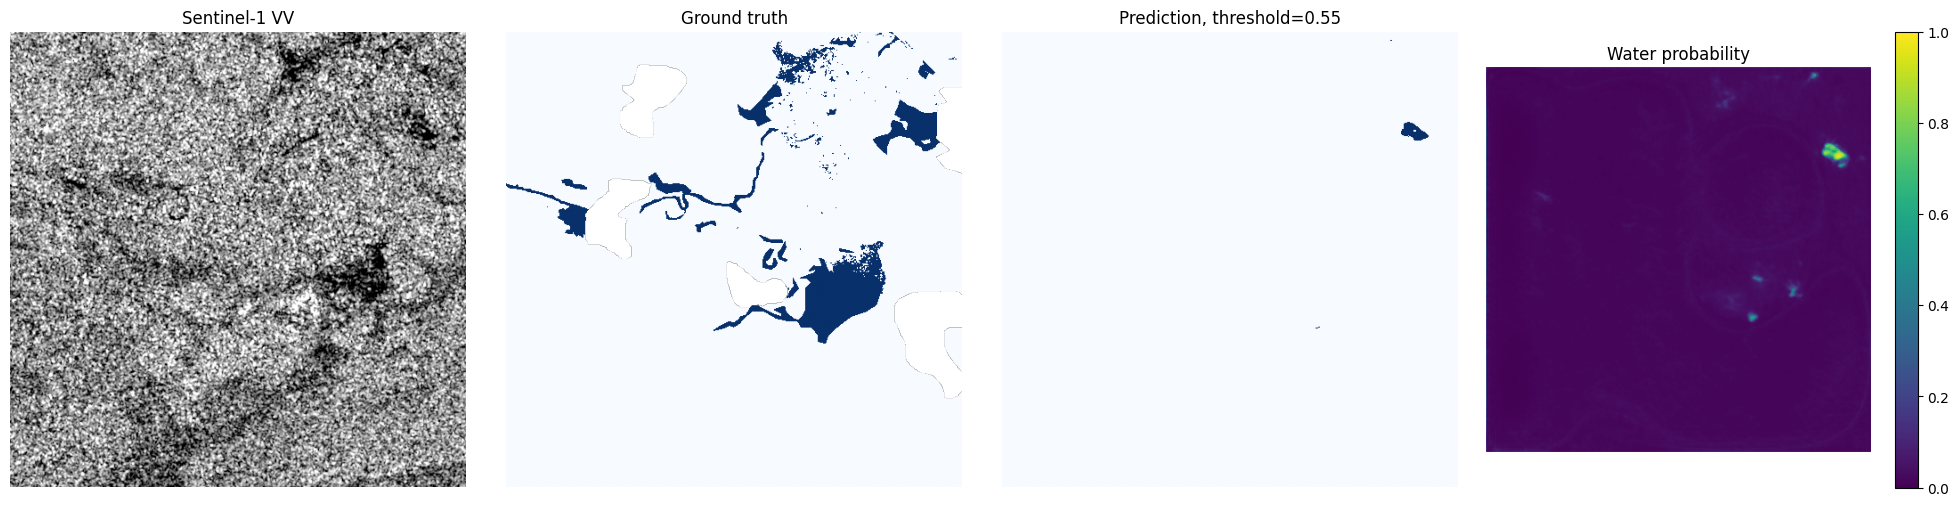

In [80]:
SAMPLE_INDEX = 0

image, mask = test_dataset[SAMPLE_INDEX]

with torch.no_grad():
    logits = model(
        image.unsqueeze(0).to(device)
    )

    probability = torch.softmax(
        logits,
        dim=1,
    )[0, 1].cpu()

prediction = (
    probability >= BEST_THRESHOLD
)

vv = (
    image[0] * 0.0820 + 0.6851
).numpy()

low, high = np.percentile(vv, [2, 98])

vv_display = np.clip(
    (vv - low) / max(high - low, 1e-8),
    0,
    1,
)

mask_display = np.ma.masked_where(
    mask.numpy() == 255,
    mask.numpy(),
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5),
)

axes[0].imshow(vv_display, cmap="gray")
axes[0].set_title("Sentinel-1 VV")

axes[1].imshow(
    mask_display,
    cmap="Blues",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Ground truth")

axes[2].imshow(
    prediction.numpy(),
    cmap="Blues",
    vmin=0,
    vmax=1,
)
axes[2].set_title(
    f"Prediction, threshold={BEST_THRESHOLD:.2f}"
)

probability_plot = axes[3].imshow(
    probability.numpy(),
    cmap="viridis",
    vmin=0,
    vmax=1,
)

axes[3].set_title("Water probability")
plt.colorbar(probability_plot, ax=axes[3])

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()